# Sammenligning av strømpriser og aluminiumspriser

Produksjon av aluminium er en strømintensiv prosess, for det kreves mye strøm for å varme og elektrolyse. Derfor kan det være naturlig at aluminiumsprisene varierer med strømprisene. Derfor vil jeg i denne oppgaven undersøke om det er tilfellet.

**Merk:** *Programmet er beregnet på at en skal kjøre cellene en gang i rekkefølge. Noen steder vil det oppstå error dersom en prøver å kjøre samme celle flere ganger på rad. Der det er tilfelle, kommenterer jeg hvorfor.*

### Importere data fra SSB

Først importerer jev to csv-filer fra SSB med data om strømprisene og aluminiumsprisene. Jeg velger å ikke lage en egen index-kolonne i aluminiumsprisene, og heller bruke den generiske indeksen med tall fra 0-n, fordi det gjør det enklere og raskere å tilpasse dataframen med den informasjonen jeg vil ha senere.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SSBENC = "ISO-8859-1"

strømpriser_df = pd.read_csv("Elektrisitetspriser_Norge.csv", 
                             encoding=SSBENC, sep=";", header=1, 
                             index_col=[0,1])

strømpriser_df

Kraftpris ekskl. avgifter (øre/kWh)  \
kontraktstype                                      kvartal                                       
HUSHOLDNINGER                                      2012K1                                 34.4   
                                                   2012K2                                 26.1   
                                                   2012K3                                 20.0   
                                                   2012K4                                 30.4   
                                                   2013K1                                 34.9   
...                                                                                        ...   
Kontrakter tilknyttet elspotprisen, kraftintens... 2022K3                                152.9   
                                                   2022K4                                103.7   
                                                   2023K1                                 74.7   
                                                   2023K2                                 53.3   
                                                   2023K3                                 31.5   

                                                           Kraftpris inkl. mva (øre/kWh)  \
kontraktstype                                      kvartal                                 
HUSHOLDNINGER                                      2012K1                           42.0   
                                                   2012K2                           31.8   
                                                   2012K3                           24.3   
                                                   2012K4                           37.1   
                                                   2013K1                           42.6   
...                                                                                  ...   
Kontrakter tilknyttet elspotprisen, kraftintens... 2022K3                              .   
                                                   2022K4                              .   
                                                   2023K1                              .   
                                                   2023K2                              .   
                                                   2023K3                              .   

                                                           Fordeling av kontraktstyper (prosent)  
kontraktstype                                      kvartal                                        
HUSHOLDNINGER                                      2012K1                                  100.0  
                                                   2012K2                                  100.0  
                                                   2012K3                                  100.0  
                                                   2012K4                                  100.0  
                                                   2013K1                                  100.0  
...                                                                                          ...  
Kontrakter tilknyttet elspotprisen, kraftintens... 2022K3                                      :  
                                                   2022K4                                      :  
                                                   2023K1                                      :  
                                                   2023K2                                      :  
                                                   2023K3                                      :  

[893 rows x 3 columns]

In [9]:
aluminiumspriser_df = pd.read_csv("Aluminiumspriser_Norge.csv", 
                             encoding=SSBENC, sep=";", header=1, )

aluminiumspriser_df

,måned,Aluminium (kr per tonn)
0,1990M01,9987.9
1,1990M02,9360.1
2,1990M03,10287.5
3,1990M04,9983.1
4,1990M05,9859.3
...,...,...
402,2023M07,18675.4
403,2023M08,16646.9
404,2023M09,16064.5
405,2023M10,16949.8


Jeg ser allerede noen utfordringer med å sammenligne datasettene. De er som følger:
* Strømprisene er inndelt i kvartaler og aluminiumsprisene er inndelt i måneder
* Aluminiumsprisene er fra 1990 og strømprisene er fra 2012
* Strømprisene er delt inn i ulike kontrakts-/abonnementtyper og der er data både fra husholdninger og fra næring og industri

Jeg vil tilpasse de to datasettene hver for seg, og ta for meg ett punkt om gangen.

### Tilpassing av dataframe med aluminiumspriser

Det første jeg vil fikse er å fjerne den delen av datasettet som ikke har tilsvarende data i strømpris-datasettet. Det vli si at jeg skal fjerne data fra og med år 1990 til og med år 2011, og informasjonen som senere vil tilhøre 4. kvartal 2023.

In [10]:
#Det skal være med fom. år 2012 tom. år 2023, men 2023 har bare data fra de 11 første månedene.
rows = (2022-2011) * 12 + 11 

#Fjerner radene med data før 2012
aluminiumspriser_df_2012_2023 = aluminiumspriser_df[-rows:]

#Fjerner oktober og november fra 2023, fordi det er et påbegynt 4. kvartal som ikke er fullført, og strømprisene
#går bare til og med 3. kvartal i 2023.
aluminiumspriser_df = aluminiumspriser_df_2012_2023[:rows-2]

aluminiumspriser_df

,måned,Aluminium (kr per tonn)
264,2012M01,12708.6
265,2012M02,12641.2
266,2012M03,12449.9
267,2012M04,11730.4
268,2012M05,11793.9
...,...,...
400,2023M05,20966.5
401,2023M06,21040.9
402,2023M07,18675.4
403,2023M08,16646.9


Det neste er å gjøre om aluminiumsprisene fra månedlig til kvartalsvis. Det gjør jeg ved å finne gjennomsnittlig pris de tre månedene i hvert kvartal.

In [11]:
#Gjøre om informasjon fra månedlig til kvartalsvis ved å gjøre om tre og tre måneder til gjennomsnittet av de tre månedene.
#Gjør også om fra kr per tonn til kr per kg ved å dividere med 1000.
n = aluminiumspriser_df.index.size
aluminiumspriser_kvartal = []
for i in range(264,405,3):
    aluminiumspriser_kvartal.append(round((aluminiumspriser_df.loc[i:i+2]["Aluminium (kr per tonn)"].mean()/1000), 1))

#Lager en liste med år og kvartal for å bruke som indeks i det oppdaterte datasettet.
index_alu = []
for år in range(2012,2024):
    for kvartal in [1,2,3,4]:
        index_alu.append(f"{år}K{kvartal}")
        
#Lager nytt dataframe med indeks som er årstall med kvartal, og gjennomsnittsprisene for hvert kvartal.
aluminiumspriser_kvartal_df = pd.DataFrame({"Aluminium (kr per kg)": aluminiumspriser_kvartal}, index = index_alu[:len(aluminiumspriser_kvartal)])

#Setter navnet på indekskolonnen til kvartal
aluminiumspriser_kvartal_df.index.name = "kvartal"

aluminiumspriser_kvartal_df

,Aluminium (kr per kg)
kvartal,
2012K1,12.6
2012K2,11.6
2012K3,11.4
2012K4,11.3
2013K1,11.3
2013K2,10.7
2013K3,10.6
2013K4,10.7
2014K1,10.4


### Tilpassing av datasett med strømpriser

Siden aluminiumsproduksjon er en strømintensiv prosess, vil jeg bruke spotprisene for strømintensiv industri som data for strømprisene. Samtidig vil jeg fjerne informasjon om kraftpris inkludert mva, og fordeling av kontraktstyper, for de er ikke relevante. Her er grunnen til at jeg bestemte kontraktstype som indeks når jeg importerte csv-filen, for da er det mye enklere å fjerne alle andre kontraktstyper enn den jeg vil bruke.

**Merk:** *Den førstkommende cellen kan ikkje kjøres igjen etter den påfølgende cellen er kjørt. Det er fordi den leter opp den delen av datasettet som har "Kontrakter tilknyttet elspotprisen [...]" i indekskolonnen "kontraktstype". Etter den påfølgende cellen er kjørt, er kontraktstype-kolonnen fjernet.*

In [12]:
#Fjerning av alle andre kontraktstyper og kunder enn elspotpris for kraftintensiv industri.
strømpriser_df = strømpriser_df.loc[['Kontrakter tilknyttet elspotprisen, kraftintensiv industri']]

#Jeg vil bare ha med kraftpris ekskl. mva videre.
strømpriser_df = strømpriser_df[["Kraftpris ekskl. avgifter (øre/kWh)"]]

strømpriser_df

Kraftpris ekskl. avgifter (øre/kWh)
kontraktstype                                      kvartal                                    
Kontrakter tilknyttet elspotprisen, kraftintens... 2012K1                                 30.1
                                                   2012K2                                 22.6
                                                   2012K3                                 15.9
                                                   2012K4                                 30.0
                                                   2013K1                                 33.9
                                                   2013K2                                 30.2
                                                   2013K3                                 30.0
                                                   2013K4                                 30.2
                                                   2014K1                                 26.2
                                                   2014K2                                 22.9
                                                   2014K3                                 28.2
                                                   2014K4                                 26.6
                                                   2015K1                                 25.1
                                                   2015K2                                 19.3
                                                   2015K3                                 14.6
                                                   2015K4                                 21.9
                                                   2016K1                                 23.8
                                                   2016K2                                 24.5
                                                   2016K3                                 24.9
                                                   2016K4                                 33.8
                                                   2017K1                                 29.9
                                                   2017K2                                 27.7
                                                   2017K3                                 25.4
                                                   2017K4                                 29.7
                                                   2018K1                                 36.7
                                                   2018K2                                 37.8
                                                   2018K3                                 48.1
                                                   2018K4                                 45.9
                                                   2019K1                                 45.8
                                                   2019K2                                 36.0
                                                   2019K3                                 33.9
                                                   2019K4                                 39.2
                                                   2020K1                                 15.9
                                                   2020K2                                  6.2
                                                   2020K3                                  5.9
                                                   2020K4                                 12.3
                                                   2021K1                                 42.7
                                                   2021K2                                 39.4
                                                   2021K3                                 64.4
                                                   2021K4                                 88.9
                                                   2022K1            

Når jeg bare har data fra den kontraktstypen jeg vil bruke, trenger ikke kontraktstypen være med i datasettet lenger. Jeg vil derfor gjøre datasettet sammenlignbart med aluminiumsprisene ved å fjerne kontraktstype og sette kolonnen med årstall og kvartal som indeks.

**Merk:** *Denne cellen kan ikke kjøres flere ganger etter hverandre. Det er fordi den fjernen kolonnen "kontraktstype". Etter det er gjort første gangen, finnes ikke kolonnen lenger, så da vil koden for å droppe den medføre error.*

In [13]:
#Gjør om indeksen i datasettet til generiske tall i stedet for kontraktstype.
strømpriser_df.reset_index(inplace=True)

#Fjerner kolonnen med kontraktstype. Axis=1 indikerer kolonne.
strømpriser_df = strømpriser_df.drop('kontraktstype', axis=1)

#Spesifiserer kolonnen med årstall og kvartal som indeks. Inplace=True overskriver strømpriser_df med det nye formatet.
strømpriser_df.set_index(['kvartal'], inplace = True)

strømpriser_df

,Kraftpris ekskl. avgifter (øre/kWh)
kvartal,
2012K1,30.1
2012K2,22.6
2012K3,15.9
2012K4,30.0
2013K1,33.9
2013K2,30.2
2013K3,30.0
2013K4,30.2
2014K1,26.2


### Undersøke om datasettene består av numeriske verdier

For å plotte datasettene må de bestå av numeriske verdier, jeg vil derfor sjekke om det er tilfellet i de to datasettene. Jeg bruker printfunksjonen som en metode for å kunne sjekke begge datasettene i samme celle, og for å kunne legge inn tomme linjer for å lettere kunne skille de to datasettene.

In [14]:
print(aluminiumspriser_kvartal_df.dtypes)
print("\n")
print(strømpriser_df.dtypes)

Aluminium (kr per kg)    float64
dtype: object


Kraftpris ekskl. avgifter (øre/kWh)    object
dtype: object


Aluminiumsprisene er rett datatype, men det er ikke strømprisene. De må derfor gjøres om til numeriske verdier.

In [15]:
strømpriser_df["Kraftpris ekskl. avgifter (øre/kWh)"]=strømpriser_df["Kraftpris ekskl. avgifter (øre/kWh)"].astype(float)

### Sammenligning av prisene - Visuelt ved linjediagram

Selv om aluminiumsprisene er oppgitt i kroner og strømprisene er oppgitt i ører, er de direkte sammenlignbare, fordi de i samme enhet (penger) og samme valuta. En grafisk framstilling av tallverdiene vil vise samme relative endring og utvikling for de to variablene.

Videre vil jeg derfor visuelt sammenligne prisene ved grafisk fremstilling som linjediagram. Jeg kommenterer funnene avslutningsvis i analysen.

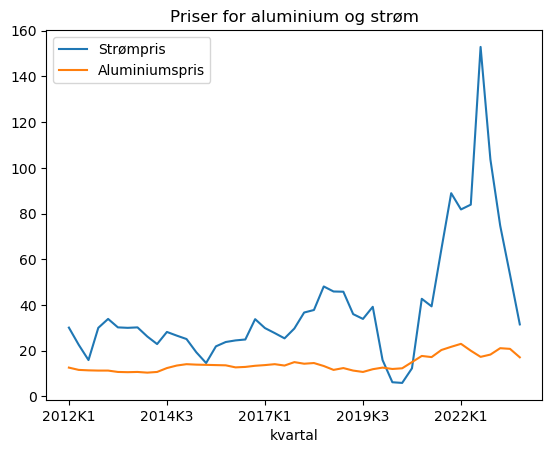

In [16]:
#Plotter prisene i de to datasettene
strømpriser_df["Kraftpris ekskl. avgifter (øre/kWh)"].plot(label="Strømpris")
aluminiumspriser_kvartal_df["Aluminium (kr per kg)"].plot(label="Aluminiumspris")
plt.title("Priser for aluminium og strøm")
plt.legend()
plt.show()

På grunn av størrelsen på de numeriske verdiene i de to datasettene, er det vanskelig å si så mye om sammenhengen mellom prisene for aluminium og strøm bare ved å se på grafene. Det kan kanskje se ut som strømprisøkningen etter 2020 har en sammenfallende økning for aluminiumsprisene. For å gjøre det lettere å sammenligne visuelt, kan jeg lage et nytt datasett for aluminiumspisen der jeg enkelt og greit multipliserer prisene med 10, for at de numeriske verdiene skal være nærmere hverandre, og på den måten lettere å sammenligne visuelt.

In [17]:
#Tilbakestiller indeksen til generiske tall for å kunne iterere over data i datasettet.
aluminiumspriser_kvartal_df.reset_index(drop=False, inplace=True)

#Gjør om prisene fra kr per kg til kr per 10kg ved å multiplisere med 10.
n = aluminiumspriser_kvartal_df.index.size
aluminiumspriser_10kg = []
for i in range(0,n,1):
    aluminiumspriser_10kg.append((aluminiumspriser_kvartal_df.loc[i]["Aluminium (kr per kg)"]) * 10)

#Lager nytt dataframe med samme indeks, og priser per 10kg for hvert kvartal.
aluminiumspriser_10kg_df = pd.DataFrame({"Aluminium (kr per 10kg)": aluminiumspriser_10kg}, index = index_alu[:len(aluminiumspriser_kvartal)])

#Navngir indekskolonnen
aluminiumspriser_10kg_df.index.name = "kvartal"

aluminiumspriser_10kg_df

,Aluminium (kr per 10kg)
kvartal,
2012K1,126.0
2012K2,116.0
2012K3,114.0
2012K4,113.0
2013K1,113.0
2013K2,107.0
2013K3,106.0
2013K4,107.0
2014K1,104.0


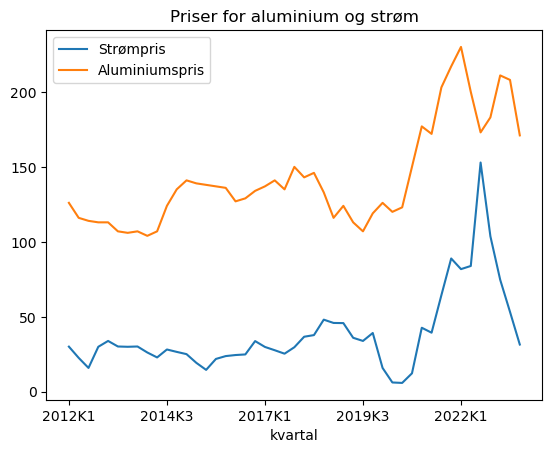

In [18]:
#Plotter på ny
strømpriser_df["Kraftpris ekskl. avgifter (øre/kWh)"].plot(label="Strømpris")
aluminiumspriser_10kg_df["Aluminium (kr per 10kg)"].plot(label="Aluminiumspris")
plt.title("Priser for aluminium og strøm")
plt.legend()
plt.show()

### Kovarians og korrelasjon

For å analysere sammenhengen mellom de to prisene videre, vil jeg sette datasettene sammen til ett dataframe, for å kunne undersøke kovarians og korrelasjon.

In [19]:
aluminiumspriser_10kg_df.reset_index(drop=False, inplace=True)

#Slår sammen datasettene.
priser_samlet_df = aluminiumspriser_10kg_df.set_index("kvartal").join(strømpriser_df)

priser_samlet_df

,Aluminium (kr per 10kg),Kraftpris ekskl. avgifter (øre/kWh)
kvartal,,
2012K1,126.0,30.1
2012K2,116.0,22.6
2012K3,114.0,15.9
2012K4,113.0,30.0
2013K1,113.0,33.9
2013K2,107.0,30.2
2013K3,106.0,30.0
2013K4,107.0,30.2
2014K1,104.0,26.2


Jeg kan nå bruke det samlede datasettet til å finne kovarians og korrelasjon mellom prisene. Jeg velger å bare finne en i hver kodecelle, for at tabellen skal se penere ut enn med vanlig print-funksjon eller om jeg finner begge i samme celle ved å sette komma mellom dem. Jeg kommenterer verdiene i analysen i slutten.

In [20]:
#Kovarians
priser_samlet_df.cov()

,Aluminium (kr per 10kg),Kraftpris ekskl. avgifter (øre/kWh)
Aluminium (kr per 10kg),1106.651249,593.921277
Kraftpris ekskl. avgifter (øre/kWh),593.921277,735.893247


In [21]:
#Korrelasjon
priser_samlet_df.corr()

,Aluminium (kr per 10kg),Kraftpris ekskl. avgifter (øre/kWh)
Aluminium (kr per 10kg),1.000000,0.658137
Kraftpris ekskl. avgifter (øre/kWh),0.658137,1.000000


### Regresjon

En annen måte å se sammenhengen på er å sette datasettene inn i et punktdiagram og finne den lineære regresjonslinjen som best illustrerer sammenhengen mellom prisene.

Stigningstallet til regresjonslinjen er 0.81


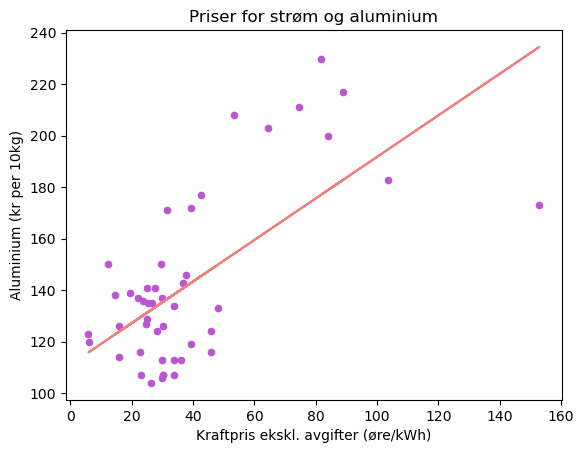

In [22]:
#Setter inn prisene i et punktdiagram
priser_samlet_df.plot.scatter(x = "Kraftpris ekskl. avgifter (øre/kWh)",
                              y = "Aluminium (kr per 10kg)",
                              c = "mediumorchid")
plt.title("Priser for strøm og aluminium")

#Definerer x-verdi og y-verdi for regresjonslinje
x = priser_samlet_df["Kraftpris ekskl. avgifter (øre/kWh)"]
y = priser_samlet_df["Aluminium (kr per 10kg)"]

#Finner stigningstall (m) og skjæringspunkt (b) for regresjonslinjen
m, b = np.polyfit(x, y, 1)

#Tegner inn regresjonslinjen
plt.plot(x, m*x+b, color = "lightcoral")

#Printer også verdien til stigningstallet
print(f"Stigningstallet til regresjonslinjen er {round(m, 2)}")

### Analyse

Visuelt sett ser det ut som det er en viss sammenheng mellom de to prisene. De kraftigeste stigningene og fallene i prisene skjer omtrent i samme periode. Ellers, når prisene er forholdsvis stabile, er det vanskeligere å se sammenheng mellom dem fra grafen.

Kovariansen er positiv, det vil si at de to prisene har en tendens til å være over gjennomsnittet på samme tid, og under gjennomsnittet på samme tid. De peker mot at de to prisene har en viss sammenheng med hverandre, men kovariansen sier ikke noe om hvor sterk denne sammenhengen er.

Korrelasjonen mellom de to prisene er på ca. 0.66. Det vil si at en økning i strømpriser i det store og hele har en effekt på aluminiumsprisene. Verdien på korrelasjonen, 0.66, sier at det er en moderat sammenheng (korrelasjon mellom 0.50 og 0.75 er somregel sett på som moderat, så innenfor den moderate sonen heller den mer mot høy enn lav).

Vi kan se tendenser til sammenhengen også i punktdiagrammet, der strømpriser rundt 60-90 øre/kWh spesielt viser positiv korrelasjon. Det er derimot ganske stor spredning på punktene fra regresjonslinjen. Det henger sammen med at det bare er moderat korrelasjon mellom prisene. Stigningstallet til regresjonslinjen (ca. 0,81) viser at om prisen på strøm øker med 1 øre/kWh, kan vi forvente at prisen stiger med 0,81 kr/10kg for aluminium. Dette hadde selvsagt vært mer nyttig informasjon om korrelasjonskoeffisienten hadde vært høyere, og dermed også punktene hadde ligget nærmere regresjonslinjen.

Det er altså en sammenheng mellom prisen på strøm og prisen på aluminium, men den er ikke svært stor i datasettet som jeg har brukt. En grunn til det kan være at strøm bare er en av innsatsfaktorene i aluminiumsproduksjonen. Malmprisene er ikke undersøkt her, men vil ha påvirkning på aluminiumsprisene også. Om prisen på bauxitt (aluminiumsrik malm) er høy, vil selvsagt det påvirke aluminiumsprisen. En tredje grunn til at sammenhengen ikke er sterkere, er at strøprisene jeg har brukt er de norske. De er bundet opp mot europeiske priser, men i andre verdensdeler der de produserer aluminium, kan det være lave strømpriser når de er høye her.

Det er også momenter som taler for sammenhengen mellom pris på strøm og aluminiumspriser. Det første er selvsagt at det brukes mye strøm i produksjonen. Det neste momentet er at strømprisene kan være påvirket av olje- og gass-prisene, siden mye strømproduksjon kommer spesielt fra gass. Høyere olje- og gasspriser vil også gjøre utvinning og transport av malm dyrere.

Til slutt vil jeg påpeke at når prisene er kvartalvise (gjennomsnitts-)priser, er det mye informasjon som går tapt, i forhold til prismålinger med kortere intervall. Det er godt mulig at sammenhengen mellom aluminiumsprisen og strømprisen hadde vært annerledes om datasettene hadde daglige priser.